# Non-Euclidean Coordinate BCDC with Gauss-Southwell Selection

This notebook implements the sparse unbalanced optimal-transport model from the attached paper,

$$
\Phi(P)=\langle C,P\rangle
  +\tau_a\operatorname{KL}(P\mathbf 1\|a)
  +\tau_b\operatorname{KL}(P^\top\mathbf 1\|b)
  +\frac{\gamma}{2}\|P\|_F^2
  +\lambda\sum_j\left(\|p_j\|_1-\|p_j\|_{(Q)}\right),\qquad P\geq 0,
$$

using entropy geometry and target columns $p_j=P_{:j}$ as BCDC blocks.  Following the
paper, a coordinate BCDC iteration first selects a target column and an admissible
subgradient of the concave top-$Q$ term at the current iterate.  The selected column
subgradient is then kept fixed while solving that one selected block subproblem:

$$v_j=\lambda\mathbf 1_{I_j}\in\lambda\,\partial\|p_j\|_{(Q)},$$

where $I_j$ contains one deterministic choice of the $Q$ largest entries.

The entropy BCDC candidate for the selected block $j$ minimizes the relative-smoothness
surrogate

$$
\langle \nabla_j f(P)-v_j,z-p_j\rangle+g_j(z)-g_j(p_j)
   +L_j\operatorname{KL}(z\|p_j),
$$

using the paper's columnwise entropy smoothness bound on the log trust region
$|\log(z_i/p_{ij})|\leq\Delta$:

$$
L_j=\tau_b+\tau_a\max_i
\frac{e^\Delta p_{ij}}{r_i+(e^\Delta-1)p_{ij}}\leq\tau_a+\tau_b.
$$

and is computed coordinatewise from

$$\gamma z_i+L_j\log(z_i/p_{ij})+d_{ij}=0,\qquad
  d_j=\nabla_j f(P)+\lambda\mathbf 1-v_j.$$

For this sparse-UOT block subproblem, the equation has a closed form via Lambert/Wright
omega, so one coordinate update exactly solves the selected block surrogate; there is no
inner coordinate loop.

We compare the requested methods:

1. **GS-Lipschitz entropy BCDC**: score sampled target columns by
   $\|q_j\|_2/\sqrt{\ell_j}$, using a current Euclidean block-Hessian upper bound
   $\ell_j$.  After selecting the column, the selected $v_j$ is fixed and the entropy
   block subproblem is solved exactly.
2. **Randomized entropy BCDC**: select one target column by random reshuffling, select
   its top-$Q$ subgradient, and solve that selected block subproblem exactly.
3. **GS-non-Euclidean-gap entropy BCDC**: score sampled target columns by the block
   contribution to Definition 2 of the paper,

   $$
   G_j(P;v_j)=\max_{z\geq0}\big\{
   \langle\nabla_j f(P)-v_j,p_j-z\rangle+g_j(p_j)-g_j(z)
   -L_j\operatorname{KL}(z\|p_j)\big\}.
   $$

   Its maximizer is exactly the entropy-BCDC candidate above, so the selected candidate
   is reused for the update.
4. **Full non-Euclidean DCA**: freeze the same selected top-$Q$ subgradient for the full
   matrix, then run inner full-matrix entropy/KL updates on that frozen convex DCA
   subproblem before refreshing the anchor.
5. **Full Euclidean DCA**: freeze the same selected top-$Q$ subgradient for the full
   matrix, then run inner projected Euclidean full-matrix updates on that frozen convex
   DCA subproblem before refreshing the anchor.

The cost accounting follows the Poisson/Burg-GS notebook: each method accumulates
`touched_nonzeros`, and the primary implementation-independent work axis is
`matvec_pass_equivalent = touched_nonzeros / (num_source * num_target)`.  Since this OT
problem is stored densely, a "nonzero" means one dense matrix entry.

## 1. Imports and experiment settings

The problem defaults below match the current notebook.  The setting
`outer_iterations_by_method` lets each method use its own budget.  For coordinate
BCDC methods, the value is the number of sweeps, so each outer unit performs
`num_target` one-column updates.  For full DCA methods, the value is the number
of outer frozen-subgradient DCA iterations.  The setting `candidate_batch_size`
controls how many target columns each Gauss-Southwell BCDC rule scores before
making its one-column update; it is not the BCDC update batch size.  With
`sampling="random_reshuffling"`, randomized BCDC reshuffles the updated columns, while
GS rules reshuffle the candidate columns and score consecutive batches from that
permutation.

The full-DCA baselines now mirror the Poisson notebook's outer/inner structure: an outer
DCA iteration freezes the concave top-$Q$ subgradient, and up to `max_inner_iterations`
full-matrix updates are applied to the frozen convex subproblem.

In [254]:
import os
import time
from dataclasses import dataclass, replace
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(".mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import wrightomega

EPS = 1e-12

plt.rcParams.update({
    "figure.figsize": (7.4, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10.5,
    "font.family": "serif",
    "font.serif": [
        "Times New Roman", "Times", "Nimbus Roman", "Liberation Serif",
        "STIXGeneral", "DejaVu Serif",
    ],
    "mathtext.fontset": "stix",
})


@dataclass(frozen=True)
class SparseOTProblem:
    cost: np.ndarray
    source_mass: np.ndarray
    target_mass: np.ndarray
    source_kl_weight: float = 20.0
    target_kl_weight: float = 20.0
    quadratic_weight: float = 1.0
    sparsity_weight: float = 1.0
    top_k: int = 2

    @property
    def num_source(self):
        return int(self.cost.shape[0])

    @property
    def num_target(self):
        return int(self.cost.shape[1])

    @property
    def entropy_relative_smoothness(self):
        return float(self.source_kl_weight + self.target_kl_weight)


@dataclass(frozen=True)
class SolverConfig:
    num_sweeps: int = 100
    selection_rule: str = "uniform"
    candidate_batch_size: int = 32
    seed: int = 0
    record_every_sweeps: int = 5
    min_plan_value: float = 1e-300
    relative_smoothness_scale: float = 1.0
    block_log_radius: float = 4.0
    sampling: str = "random_reshuffling"
    max_inner_iterations: int = 50
    inner_tol: float = 1e-12

    def validate(self, num_target):
        valid = {"uniform", "gradient", "lipschitz", "bregman_gap"}
        if self.selection_rule not in valid:
            raise ValueError(f"selection_rule must be one of {sorted(valid)}")
        if self.num_sweeps <= 0 or self.record_every_sweeps <= 0:
            raise ValueError("Sweep counts must be positive.")
        if not 1 <= self.candidate_batch_size <= num_target:
            raise ValueError("candidate_batch_size must be between 1 and num_target.")
        if self.min_plan_value <= 0.0:
            raise ValueError("min_plan_value must be strictly positive.")
        if self.relative_smoothness_scale <= 0.0:
            raise ValueError("relative_smoothness_scale must be positive.")
        if self.block_log_radius is not None:
            radius = float(self.block_log_radius)
            if np.isnan(radius) or radius <= 0.0:
                raise ValueError("block_log_radius must be positive or np.inf.")
            if np.isfinite(radius) and radius > 50.0:
                raise ValueError("Use np.inf to recover the global entropy constant.")
        if self.sampling not in {"uniform", "random_reshuffling"}:
            raise ValueError("sampling must be 'uniform' or 'random_reshuffling'.")
        if self.max_inner_iterations <= 0:
            raise ValueError("max_inner_iterations must be positive.")
        if self.inner_tol < 0.0:
            raise ValueError("inner_tol must be nonnegative.")



CONFIG = {
    "num_source": 256,
    "num_target": 512,
    "dimension": 128,
    "top_k": 2,
    "source_kl_weight": 100.0,
    "target_kl_weight": 100.0,
    "quadratic_weight": 0.5,
    "sparsity_weight": 10.0,
    "target_mass_log_std": 0.0,
    "outlier_fraction": 0.0,
    "outlier_shift": 0.0,
    "noise_std": 0.0,
    "problem_seed": 0,
    "solver_seed": 0,
    # Fallback outer-iteration budget.  Per-method values below override it.
    "num_sweeps": 100,
    # For BCDC methods, these are sweeps, and one sweep equals num_target
    # one-column updates.  For full DCA methods, these are outer DCA
    # iterations, each freezing the full top-Q subgradient once.
    "outer_iterations_by_method": {
        "lipschitz": 1000,
        "uniform": 6000,
        "bregman_gap": 1000,
        "full_entropy": 100,
        "full_euclidean": 100,
    },
    "record_every_sweeps": 1,
    "min_plan_value": 1e-300,
    "relative_smoothness_scale": 1.0,
    # Paper's Delta in the column trust region |log(z_i / p_ij)| <= Delta.
    # Use np.inf to recover the previous global L = tau_a + tau_b update.
    "block_log_radius": 4.0,
    "candidate_batch_size": 8,   # GS-only parameter
    # Fallback full-DCA inner budget.  Per-method values below override it.
    "max_inner_iterations": 100,
    "max_inner_iterations_by_method": {
        "full_entropy": 100,
        "full_euclidean": 100,
    },
    "inner_tol": 1e-9,
}

## 2. Synthetic sparse unbalanced-OT problem

Each target is generated near a convex combination of `top_k` source points, with optional outliers.
The source and target masses are positive and have the same total mass, although the UOT objective
does not enforce exact marginal equality.


In [255]:
def generalized_kl(x, y):
    x = np.maximum(np.asarray(x, dtype=np.float64), EPS)
    y = np.maximum(np.asarray(y, dtype=np.float64), EPS)
    return float(np.sum(x * np.log(x / y) - x + y))


def make_clustered_problem(
    num_source=64,
    num_target=120,
    dimension=4,
    top_k=2,
    source_kl_weight=20.0,
    target_kl_weight=20.0,
    quadratic_weight=1.0,
    sparsity_weight=1.0,
    target_mass_log_std=0.4,
    outlier_fraction=0.1,
    outlier_shift=3.0,
    noise_std=0.05,
    seed=0,
):
    if min(num_source, num_target, dimension) <= 0:
        raise ValueError("Problem dimensions must be positive.")
    if not 1 <= top_k <= num_source:
        raise ValueError("top_k must be between 1 and num_source.")

    rng = np.random.default_rng(seed)
    source_points = rng.normal(size=(num_source, dimension))
    source_points /= np.maximum(
        np.linalg.norm(source_points, axis=1, keepdims=True), EPS
    )

    support = np.vstack([
        rng.choice(num_source, size=top_k, replace=False)
        for _ in range(num_target)
    ])
    weights = rng.random((num_target, top_k))
    weights /= weights.sum(axis=1, keepdims=True)
    target_points = np.zeros((num_target, dimension))
    for q in range(top_k):
        target_points += weights[:, q, None] * source_points[support[:, q]]
    target_points += noise_std * rng.normal(size=target_points.shape)

    num_outliers = int(round(outlier_fraction * num_target))
    if num_outliers:
        idx = rng.choice(num_target, size=num_outliers, replace=False)
        directions = rng.normal(size=(num_outliers, dimension))
        directions /= np.maximum(
            np.linalg.norm(directions, axis=1, keepdims=True), EPS
        )
        target_points[idx] += outlier_shift * directions

    diff = source_points[:, None, :] - target_points[None, :, :]
    cost = np.sum(diff * diff, axis=2)
    target_mass = np.exp(target_mass_log_std * rng.normal(size=num_target))
    target_mass *= num_target / target_mass.sum()
    source_mass = np.full(num_source, target_mass.sum() / num_source)
    return SparseOTProblem(
        cost=np.ascontiguousarray(cost),
        source_mass=np.ascontiguousarray(source_mass),
        target_mass=np.ascontiguousarray(target_mass),
        source_kl_weight=float(source_kl_weight),
        target_kl_weight=float(target_kl_weight),
        quadratic_weight=float(quadratic_weight),
        sparsity_weight=float(sparsity_weight),
        top_k=int(top_k),
    )


def initialize_plan(problem):
    total = float(problem.source_mass.sum())
    plan = np.outer(problem.source_mass, problem.target_mass) / total
    return np.maximum(plan, EPS)


def topq_indices(x, q):
    q = min(max(int(q), 0), x.size)
    if q == 0:
        return np.empty(0, dtype=np.int64)
    if q == x.size:
        return np.arange(x.size, dtype=np.int64)
    # One admissible extreme subgradient is enough, including at ties.
    return np.argpartition(x, -q)[-q:]


def topq_value(x, q):
    return float(np.sum(x[topq_indices(x, q)]))


def selected_topq_subgradient(x, q, weight):
    v = np.zeros_like(x, dtype=np.float64)
    v[topq_indices(x, q)] = weight
    return v


def objective_value(problem, plan, source_marginal=None, target_marginal=None):
    if source_marginal is None:
        source_marginal = plan.sum(axis=1)
    if target_marginal is None:
        target_marginal = plan.sum(axis=0)
    trimmed = sum(
        float(plan[:, j].sum()) - topq_value(plan[:, j], problem.top_k)
        for j in range(problem.num_target)
    )
    return float(
        np.sum(problem.cost * plan)
        + problem.source_kl_weight * generalized_kl(source_marginal, problem.source_mass)
        + problem.target_kl_weight * generalized_kl(target_marginal, problem.target_mass)
        + 0.5 * problem.quadratic_weight * np.sum(plan * plan)
        + problem.sparsity_weight * trimmed
    )


## 3. Entropy BCDC candidates, frozen full-DCA subproblems, and scores

`entropy_bcdc_candidate` solves the scalar optimality equations exactly (up to
floating-point precision) with `scipy.special.wrightomega`, which avoids overflow in
the Lambert-$W$ expression.  For coordinate methods the unconstrained log update is
clipped to the paper's trust region `block_log_radius = Delta`; setting this value to
`np.inf` recovers the previous global-constant behavior.

The normalized Euclidean GS rule uses the local block-Hessian upper bound

$$
\ell_j=\gamma+\tau_a\max_i\frac{1}{r_i}+\tau_b\frac{m}{s_j}
   \ \geq\ \lambda_{\max}\!\left(
   \gamma I+\tau_a\operatorname{Diag}(1/r)+\frac{\tau_b}{s_j}\mathbf1\mathbf1^\top
   \right).
$$

For a full Euclidean update inside a frozen DCA subproblem, the full-matrix Hessian is bounded by

$$
\ell_{\mathrm{full}}
=\gamma+\tau_a\frac{n}{\min_i r_i}+\tau_b\frac{m}{\min_j s_j}.
$$

The full baselines now use a Poisson-notebook-style outer/inner pattern: freeze the concave
top-$Q$ subgradient once per outer DCA iteration, then perform inner full-matrix updates on
that frozen convex subproblem until either `inner_tol` is met or `max_inner_iterations` is
reached.
The GS batch scoring path is vectorized: the Euclidean normalized scores and the non-Euclidean gap scores are computed for all sampled candidate columns in one dense block operation before the single selected column is updated.


In [256]:
def block_gradient_f(problem, source_marginal, target_marginal, j):
    r = np.maximum(source_marginal, EPS)
    sj = max(float(target_marginal[j]), EPS)
    return (
        problem.cost[:, j]
        + problem.source_kl_weight * np.log(r / problem.source_mass)
        + problem.target_kl_weight * np.log(sj / problem.target_mass[j])
    )


def block_gradient_f_batch(problem, source_marginal, target_marginal, candidates):
    candidates = np.asarray(candidates, dtype=np.int64)
    r = np.maximum(source_marginal, EPS)
    sj = np.maximum(target_marginal[candidates], EPS)
    return (
        problem.cost[:, candidates]
        + problem.source_kl_weight * np.log(r / problem.source_mass)[:, None]
        + problem.target_kl_weight
        * np.log(sj / problem.target_mass[candidates])[None, :]
    )


def log_trust_region_bounds(p, log_radius, min_value=EPS):
    if log_radius is None:
        return None, None
    radius = float(log_radius)
    if not np.isfinite(radius):
        return None, None
    p = np.maximum(np.asarray(p, dtype=np.float64), min_value)
    lower = np.maximum(p * np.exp(-radius), min_value)
    upper = np.maximum(p * np.exp(radius), lower)
    return lower, upper


def entropy_bcdc_candidate(
    p, d, relative_smoothness, gamma, min_value=EPS, log_radius=None
):
    p = np.maximum(np.asarray(p, dtype=np.float64), min_value)
    d = np.asarray(d, dtype=np.float64)
    L = np.asarray(relative_smoothness, dtype=np.float64)
    gamma = float(gamma)
    if np.any(L <= 0.0):
        raise ValueError("The entropy relative-smoothness weight must be positive.")
    if gamma == 0.0:
        log_z = np.log(p) - d / L
        z = np.exp(np.clip(log_z, np.log(min_value), np.log(np.finfo(float).max)))
    else:
        log_argument = np.log(gamma * p / L) - d / L
        z = (L / gamma) * wrightomega(log_argument)
    lower, upper = log_trust_region_bounds(p, log_radius, min_value)
    if lower is not None:
        z = np.minimum(np.maximum(z, lower), upper)
    return np.maximum(np.asarray(z, dtype=np.float64), min_value)




def columnwise_entropy_smoothness(problem, source_marginal, p, config):
    radius = config.block_log_radius
    base = problem.entropy_relative_smoothness
    if radius is None or not np.isfinite(float(radius)):
        return float(base * config.relative_smoothness_scale)

    alpha = np.exp(float(radius))
    r = np.maximum(np.asarray(source_marginal, dtype=np.float64), EPS)
    p = np.maximum(np.asarray(p, dtype=np.float64), config.min_plan_value)
    denominator = np.maximum(r + np.expm1(float(radius)) * p, EPS)
    source_fraction = np.clip(alpha * p / denominator, 0.0, 1.0)
    local_L = (
        problem.target_kl_weight
        + problem.source_kl_weight * float(np.max(source_fraction))
    )
    return float(local_L * config.relative_smoothness_scale)


def columnwise_entropy_smoothness_batch(problem, source_marginal, p, config):
    radius = config.block_log_radius
    p = np.asarray(p, dtype=np.float64)
    if radius is None or not np.isfinite(float(radius)):
        return np.full(
            p.shape[1],
            problem.entropy_relative_smoothness * config.relative_smoothness_scale,
            dtype=np.float64,
        )

    alpha = np.exp(float(radius))
    r = np.maximum(np.asarray(source_marginal, dtype=np.float64), EPS)[:, None]
    p_safe = np.maximum(p, config.min_plan_value)
    denominator = np.maximum(r + np.expm1(float(radius)) * p_safe, EPS)
    source_fraction = np.clip(alpha * p_safe / denominator, 0.0, 1.0)
    local_L = (
        problem.target_kl_weight
        + problem.source_kl_weight * np.max(source_fraction, axis=0)
    )
    return np.asarray(local_L * config.relative_smoothness_scale, dtype=np.float64)


def entropy_kl(z, p):
    z = np.maximum(np.asarray(z, dtype=np.float64), 1e-300)
    p = np.maximum(np.asarray(p, dtype=np.float64), 1e-300)
    return float(np.sum(z * np.log(z / p) - z + p))


def entropy_kl_columns(z, p):
    z = np.maximum(np.asarray(z, dtype=np.float64), 1e-300)
    p = np.maximum(np.asarray(p, dtype=np.float64), 1e-300)
    return np.sum(z * np.log(z / p) - z + p, axis=0)


def relative_objective_change(previous, current):
    return float(abs(current - previous) / max(1.0, abs(previous)))


def projected_block_gradient(gradient, p, min_value):
    gradient = np.asarray(gradient, dtype=np.float64).copy()
    active_lower = p <= min_value * (1.0 + 1e-8)
    # At the numerical lower bound, a positive gradient only requests an infeasible decrease.
    gradient[active_lower & (gradient > 0.0)] = 0.0
    return gradient


def projected_block_gradient_batch(gradient, p, min_value):
    projected = np.asarray(gradient, dtype=np.float64).copy()
    active_lower = p <= min_value * (1.0 + 1e-8)
    projected[active_lower & (projected > 0.0)] = 0.0
    return projected


def local_euclidean_lipschitz_bound(problem, source_marginal, target_marginal, j):
    r_min = max(float(np.min(source_marginal)), EPS)
    sj = max(float(target_marginal[j]), EPS)
    return float(
        problem.quadratic_weight
        + problem.source_kl_weight / r_min
        + problem.target_kl_weight * problem.num_source / sj
    )


def local_euclidean_lipschitz_bounds(problem, source_marginal, target_marginal, candidates):
    candidates = np.asarray(candidates, dtype=np.int64)
    r_min = max(float(np.min(source_marginal)), EPS)
    sj = np.maximum(target_marginal[candidates], EPS)
    return (
        problem.quadratic_weight
        + problem.source_kl_weight / r_min
        + problem.target_kl_weight * problem.num_source / sj
    )


def selected_topq_subgradient_batch(values, q, weight):
    values = np.asarray(values, dtype=np.float64)
    if values.ndim != 2:
        raise ValueError("values must be a two-dimensional array.")
    m, b = values.shape
    q = min(max(int(q), 0), m)
    v = np.zeros_like(values, dtype=np.float64)
    if q == 0 or b == 0:
        return v
    if q == m:
        v[:, :] = weight
        return v
    rows = np.argpartition(values, -q, axis=0)[-q:, :]
    cols = np.arange(b, dtype=np.int64)[None, :]
    v[rows, cols] = weight
    return v


def block_terms_with_selected_subgradient(
    problem, plan, source_marginal, target_marginal, j, v_j=None
):
    p = plan[:, j]
    grad_f = block_gradient_f(problem, source_marginal, target_marginal, j)
    if v_j is None:
        v_j = selected_topq_subgradient(
            p, problem.top_k, problem.sparsity_weight
        )
    else:
        v_j = np.asarray(v_j, dtype=np.float64).copy()
    d = grad_f + problem.sparsity_weight - v_j
    selected_dc_gradient = d + problem.quadratic_weight * p
    return p, v_j, d, selected_dc_gradient


def block_terms_with_selected_subgradient_batch(
    problem, plan, source_marginal, target_marginal, candidates, v_batch=None
):
    candidates = np.asarray(candidates, dtype=np.int64)
    p = plan[:, candidates]
    grad_f = block_gradient_f_batch(
        problem, source_marginal, target_marginal, candidates
    )
    if v_batch is None:
        v_batch = selected_topq_subgradient_batch(
            p, problem.top_k, problem.sparsity_weight
        )
    else:
        v_batch = np.asarray(v_batch, dtype=np.float64).copy()
    d = grad_f + problem.sparsity_weight - v_batch
    selected_dc_gradient = d + problem.quadratic_weight * p
    return p, v_batch, d, selected_dc_gradient


def evaluate_block(
    problem, plan, source_marginal, target_marginal, j, config,
    need_candidate, v_j=None
):
    p, selected_v, d, selected_dc_gradient = block_terms_with_selected_subgradient(
        problem, plan, source_marginal, target_marginal, j, v_j=v_j
    )
    projected_gradient = projected_block_gradient(
        selected_dc_gradient, p, config.min_plan_value
    )

    candidate = None
    gap = None
    if need_candidate:
        L = columnwise_entropy_smoothness(
            problem, source_marginal, p, config
        )
        candidate = entropy_bcdc_candidate(
            p,
            d,
            L,
            problem.quadratic_weight,
            config.min_plan_value,
            log_radius=config.block_log_radius,
        )
        gap = (
            float(np.dot(d, p - candidate))
            + 0.5 * problem.quadratic_weight
            * float(np.dot(p, p) - np.dot(candidate, candidate))
            - L * entropy_kl(candidate, p)
        )
        gap = max(float(gap), 0.0)

    if config.selection_rule == "uniform":
        score = np.nan
    elif config.selection_rule == "gradient":
        score = float(np.linalg.norm(projected_gradient))
    elif config.selection_rule == "lipschitz":
        ell = local_euclidean_lipschitz_bound(
            problem, source_marginal, target_marginal, j
        )
        score = float(np.linalg.norm(projected_gradient) / np.sqrt(max(ell, EPS)))
    elif config.selection_rule == "bregman_gap":
        score = float(gap)
    else:
        raise ValueError(config.selection_rule)

    return score, candidate, selected_dc_gradient, gap, selected_v


def evaluate_block_batch(
    problem, plan, source_marginal, target_marginal, candidates, config,
    need_candidate
):
    candidates = np.asarray(candidates, dtype=np.int64)
    if candidates.size == 0:
        raise ValueError("At least one candidate column is required.")
    need_candidate = bool(need_candidate or config.selection_rule == "bregman_gap")
    p, selected_v, d, selected_dc_gradient = block_terms_with_selected_subgradient_batch(
        problem, plan, source_marginal, target_marginal, candidates
    )
    projected_gradient = projected_block_gradient_batch(
        selected_dc_gradient, p, config.min_plan_value
    )

    candidate = None
    gap = None
    if need_candidate:
        L = columnwise_entropy_smoothness_batch(
            problem, source_marginal, p, config
        )
        candidate = entropy_bcdc_candidate(
            p,
            d,
            L,
            problem.quadratic_weight,
            config.min_plan_value,
            log_radius=config.block_log_radius,
        )
        gap = (
            np.sum(d * (p - candidate), axis=0)
            + 0.5 * problem.quadratic_weight
            * (np.sum(p * p, axis=0) - np.sum(candidate * candidate, axis=0))
            - L * entropy_kl_columns(candidate, p)
        )
        gap = np.maximum(gap.astype(np.float64), 0.0)

    if config.selection_rule == "uniform":
        score = np.full(candidates.size, np.nan, dtype=np.float64)
    elif config.selection_rule == "gradient":
        score = np.linalg.norm(projected_gradient, axis=0)
    elif config.selection_rule == "lipschitz":
        ell = local_euclidean_lipschitz_bounds(
            problem, source_marginal, target_marginal, candidates
        )
        score = np.linalg.norm(projected_gradient, axis=0) / np.sqrt(
            np.maximum(ell, EPS)
        )
    elif config.selection_rule == "bregman_gap":
        score = gap
    else:
        raise ValueError(config.selection_rule)

    return score, candidate, selected_dc_gradient, gap, selected_v


def solve_selected_coordinate_subproblem(
    problem, plan, source_marginal, target_marginal, j, selected_v, config,
    precomputed_candidate=None
):
    if precomputed_candidate is not None:
        return precomputed_candidate
    _, candidate, _, _, _ = evaluate_block(
        problem, plan, source_marginal, target_marginal, j, config,
        need_candidate=True, v_j=selected_v
    )
    return candidate


def choose_block(problem, plan, source_marginal, target_marginal, config, rng,
                 forced_uniform_block=None, forced_candidates=None):
    n = problem.num_target
    m = problem.num_source
    if config.selection_rule == "uniform":
        j = int(rng.integers(n) if forced_uniform_block is None else forced_uniform_block)
        score, candidate, _, _, selected_v = evaluate_block(
            problem, plan, source_marginal, target_marginal, j, config,
            need_candidate=True
        )
        return j, selected_v, candidate, score, 0, 0

    batch_size = min(config.candidate_batch_size, n)
    if forced_candidates is None:
        candidates = rng.choice(n, size=batch_size, replace=False)
    else:
        candidates = np.asarray(forced_candidates, dtype=np.int64)
        if candidates.size == 0:
            raise ValueError("A GS candidate batch must contain at least one column.")
    need_all_candidates = config.selection_rule == "bregman_gap"

    # Same work model as the Poisson notebook: GS scoring touches candidate columns
    # once for gradient information and once for curvature/score information.
    selection_columns = int(candidates.size)
    selection_touched = int(2 * m * candidates.size)

    scores, candidates_z, _, _, selected_v = evaluate_block_batch(
        problem, plan, source_marginal, target_marginal, candidates, config,
        need_candidate=need_all_candidates
    )
    best_pos = int(np.argmax(scores))
    best_j = int(candidates[best_pos])
    best_score = float(scores[best_pos])
    best_candidate = (
        None if candidates_z is None else candidates_z[:, best_pos].copy()
    )
    best_v = selected_v[:, best_pos].copy()

    return best_j, best_v, best_candidate, best_score, selection_columns, selection_touched

def selected_topq_subgradient_matrix(problem, plan):
    v = np.zeros_like(plan, dtype=np.float64)
    for j in range(problem.num_target):
        v[topq_indices(plan[:, j], problem.top_k), j] = problem.sparsity_weight
    return v


def full_gradient_f(problem, source_marginal, target_marginal):
    r = np.maximum(source_marginal, EPS)
    s = np.maximum(target_marginal, EPS)
    return (
        problem.cost
        + problem.source_kl_weight * np.log(r / problem.source_mass)[:, None]
        + problem.target_kl_weight * np.log(s / problem.target_mass)[None, :]
    )


def full_selected_dc_terms_with_anchor(problem, plan, source_marginal, target_marginal, v_anchor):
    d = (
        full_gradient_f(problem, source_marginal, target_marginal)
        + problem.sparsity_weight
        - v_anchor
    )
    selected_dc_gradient = d + problem.quadratic_weight * plan
    return d, selected_dc_gradient


def full_subproblem_objective(problem, plan, source_marginal, target_marginal, v_anchor):
    return float(
        np.sum(problem.cost * plan)
        + problem.source_kl_weight * generalized_kl(source_marginal, problem.source_mass)
        + problem.target_kl_weight * generalized_kl(target_marginal, problem.target_mass)
        + 0.5 * problem.quadratic_weight * np.sum(plan * plan)
        + problem.sparsity_weight * np.sum(plan)
        - float(np.sum(v_anchor * plan))
    )


def full_entropy_candidate_with_anchor(problem, plan, source_marginal, target_marginal, v_anchor, config):
    d, _ = full_selected_dc_terms_with_anchor(
        problem, plan, source_marginal, target_marginal, v_anchor
    )
    L = problem.entropy_relative_smoothness * config.relative_smoothness_scale
    return entropy_bcdc_candidate(
        plan,
        d,
        L,
        problem.quadratic_weight,
        config.min_plan_value,
    )


def full_euclidean_lipschitz_bound(problem, source_marginal, target_marginal):
    r_min = max(float(np.min(source_marginal)), EPS)
    s_min = max(float(np.min(target_marginal)), EPS)
    return float(
        problem.quadratic_weight
        + problem.source_kl_weight * problem.num_target / r_min
        + problem.target_kl_weight * problem.num_source / s_min
    )


def full_euclidean_candidate_with_anchor(problem, plan, source_marginal, target_marginal, v_anchor, config):
    _, selected_dc_gradient = full_selected_dc_terms_with_anchor(
        problem, plan, source_marginal, target_marginal, v_anchor
    )
    ell = (
        full_euclidean_lipschitz_bound(problem, source_marginal, target_marginal)
        * config.relative_smoothness_scale
    )
    candidate = np.maximum(
        plan - selected_dc_gradient / max(ell, EPS),
        config.min_plan_value,
    )
    return candidate, float(ell)

## 4. Solvers, diagnostics, and Poisson-style cost accounting

A coordinate BCDC step follows the paper's selected-pair structure.  It first selects a
target column and a concrete top-$Q$ subgradient for that column, then solves the selected
column surrogate exactly while keeping all other columns unchanged.  Because the sparse-UOT
block subproblem has the closed form from the paper, there is no inner coordinate loop.

The full methods follow the Poisson notebook's outer/inner DCA structure.  At each outer
iteration they freeze the concave top-$Q$ subgradient for the full matrix, then perform up to
`max_inner_iterations` full-matrix updates on that frozen convex subproblem.

Cost accounting also follows the Poisson notebook.  `touched_nonzeros` counts dense entries
touched by gradient/curvature/update passes, and
`matvec_pass_equivalent = touched_nonzeros / (num_source * num_target)`.

In [257]:
BCDC_COMPARISON_RULES = ("lipschitz", "uniform", "bregman_gap")
FULL_COMPARISON_METHODS = ("full_entropy", "full_euclidean")
COMPARISON_METHODS = BCDC_COMPARISON_RULES + FULL_COMPARISON_METHODS

METHOD_LABELS = {
    "uniform": "Randomized entropy-BCDC",
    "gradient": "GS-gradient entropy-BCDC",
    "lipschitz": "GS-Lipschitz entropy-BCDC",
    "bregman_gap": "GS-non-Euclidean-gap entropy-BCDC",
    "full_entropy": "Full non-Euclidean DCA",
    "full_euclidean": "Full Euclidean DCA",
}


def resolve_method_integer_budgets(overrides, default, name, allowed_methods=None):
    allowed = tuple(COMPARISON_METHODS if allowed_methods is None else allowed_methods)
    overrides = {} if overrides is None else dict(overrides)
    unknown = sorted(set(overrides) - set(allowed))
    if unknown:
        raise ValueError(
            f"{name} contains unknown method keys: {unknown}. "
            f"Allowed keys are {list(allowed)}."
        )
    budgets = {}
    for method_key in allowed:
        value = overrides.get(method_key, default)
        if isinstance(value, bool):
            raise ValueError(f"{name}[{method_key!r}] must be a positive integer.")
        value = int(value)
        if value <= 0:
            raise ValueError(f"{name}[{method_key!r}] must be positive.")
        budgets[method_key] = value
    return budgets


def build_method_config(
    base_config, method_key, outer_iterations_by_method,
    max_inner_iterations_by_method
):
    if method_key not in COMPARISON_METHODS:
        raise ValueError(f"Unknown comparison method {method_key!r}.")
    cfg = replace(
        base_config,
        num_sweeps=int(outer_iterations_by_method[method_key]),
        max_inner_iterations=int(max_inner_iterations_by_method[method_key]),
    )
    if method_key in BCDC_COMPARISON_RULES:
        cfg = replace(cfg, selection_rule=method_key)
    return cfg


def make_method_budget_table(outer_iterations_by_method, max_inner_iterations_by_method,
                             num_target):
    rows = []
    for method_key in COMPARISON_METHODS:
        if method_key in BCDC_COMPARISON_RULES:
            budget_kind = "BCDC sweeps"
            coordinate_updates_per_outer = "num_target"
            total_coordinate_updates = (
                int(outer_iterations_by_method[method_key]) * int(num_target)
            )
        else:
            budget_kind = "full DCA outer iterations"
            coordinate_updates_per_outer = "full matrix"
            total_coordinate_updates = np.nan
        rows.append({
            "method": METHOD_LABELS[method_key],
            "method_key": method_key,
            "budget_kind": budget_kind,
            "configured_outer_iterations": int(outer_iterations_by_method[method_key]),
            "coordinate_updates_per_outer": coordinate_updates_per_outer,
            "configured_coordinate_updates": total_coordinate_updates,
            "configured_max_inner_iterations": int(max_inner_iterations_by_method[method_key]),
        })
    return pd.DataFrame(rows)


def dense_problem_nnz(problem):
    return int(problem.num_source * problem.num_target)


def init_counters():
    return {
        "wall_clock_time": 0.0,
        "optimization_time": 0.0,
        "touched_nonzeros": 0,
        "column_accesses": 0,
        "objective_evaluations": 0,
        "mean_step_size": 0.0,
        "acceptance_rate": 1.0,
        "number_backtracking_steps": 0,
    }


def selected_subgradient_full_gap(problem, plan, source_marginal, target_marginal, config):
    gap = 0.0
    diagnostic_config = replace(config, selection_rule="bregman_gap")
    for j in range(problem.num_target):
        _, _, _, block_gap, _ = evaluate_block(
            problem, plan, source_marginal, target_marginal, j,
            diagnostic_config, need_candidate=True
        )
        gap += block_gap
    return float(max(gap, 0.0))


def selected_subgradient_kkt_residual(problem, plan, source_marginal, target_marginal, config):
    squared = 0.0
    for j in range(problem.num_target):
        _, _, gradient, _, _ = evaluate_block(
            problem, plan, source_marginal, target_marginal, j,
            replace(config, selection_rule="gradient"), need_candidate=False
        )
        projected = projected_block_gradient(
            gradient, plan[:, j], config.min_plan_value
        )
        squared += float(np.dot(projected, projected))
    return float(np.sqrt(squared))


def make_history_row(problem, plan, source_marginal, target_marginal, config,
                     iteration, sweep, counters, selected_score,
                     method_key=None, outer_iteration=None, inner_iterations=None,
                     subproblem_obj_change=np.nan, subproblem_converged=False):
    method_key = config.selection_rule if method_key is None else method_key
    source_residual = float(
        np.sum(np.abs(source_marginal - problem.source_mass))
        / np.sum(problem.source_mass)
    )
    target_residual = float(
        np.sum(np.abs(target_marginal - problem.target_mass))
        / np.sum(problem.target_mass)
    )
    dense_nnz = dense_problem_nnz(problem)
    matvec_pass_equivalent = (
        float(counters["touched_nonzeros"] / dense_nnz)
        if dense_nnz > 0 else np.nan
    )
    return {
        "method": METHOD_LABELS[method_key],
        "method_key": method_key,
        "configured_outer_iterations": int(config.num_sweeps),
        "configured_max_inner_iterations": int(config.max_inner_iterations),
        "outer_iteration": int(iteration if outer_iteration is None else outer_iteration),
        "inner_iterations": int(iteration if inner_iterations is None else inner_iterations),
        "iteration": int(iteration),
        "sweep": float(sweep),
        "optimization_time_seconds": float(counters["optimization_time"]),
        "wall_clock_time": float(counters["wall_clock_time"]),
        "touched_nonzeros": int(counters["touched_nonzeros"]),
        "column_accesses": int(counters["column_accesses"]),
        "objective_evaluations": int(counters["objective_evaluations"]),
        "matvec_pass_equivalent": matvec_pass_equivalent,
        "matvec_sweeps": matvec_pass_equivalent,
        "selected_score": float(selected_score),
        "subproblem_obj_change": float(subproblem_obj_change),
        "subproblem_converged": bool(subproblem_converged),
        "objective": objective_value(
            problem, plan, source_marginal, target_marginal
        ),
        "non_euclidean_gap_selected_v": selected_subgradient_full_gap(
            problem, plan, source_marginal, target_marginal, config
        ),
        "selected_v_kkt_residual": selected_subgradient_kkt_residual(
            problem, plan, source_marginal, target_marginal, config
        ),
        "source_marginal_relative_l1_residual": source_residual,
        "target_marginal_relative_l1_residual": target_residual,
        "marginal_relative_l1_residual": max(source_residual, target_residual),
        "topq_mass_fraction": float(
            sum(topq_value(plan[:, j], problem.top_k) for j in range(problem.num_target))
            / max(float(plan.sum()), EPS)
        ),
        "mean_step_size": float(counters["mean_step_size"]),
        "acceptance_rate": float(counters["acceptance_rate"]),
        "number_backtracking_steps": int(counters["number_backtracking_steps"]),
    }


def append_history_row(rows, problem, plan, source_marginal, target_marginal, config,
                       iteration, sweep, counters, selected_score, t0,
                       method_key=None, outer_iteration=None, inner_iterations=None,
                       subproblem_obj_change=np.nan, subproblem_converged=False):
    counters["objective_evaluations"] += 1
    counters["wall_clock_time"] = time.perf_counter() - t0
    diagnostic_start = time.perf_counter()
    rows.append(make_history_row(
        problem, plan, source_marginal, target_marginal, config,
        iteration=iteration, sweep=sweep, counters=counters,
        selected_score=selected_score, method_key=method_key,
        outer_iteration=outer_iteration, inner_iterations=inner_iterations,
        subproblem_obj_change=subproblem_obj_change,
        subproblem_converged=subproblem_converged,
    ))
    return t0 + (time.perf_counter() - diagnostic_start)




def next_random_reshuffled_candidate_batch(rng, state, num_target, batch_size):
    num_target = int(num_target)
    batch_size = min(max(int(batch_size), 1), num_target)
    if state.get("order") is None or int(state.get("position", 0)) >= num_target:
        state["order"] = rng.permutation(num_target)
        state["position"] = 0

    start = int(state["position"])
    stop = min(start + batch_size, num_target)
    state["position"] = stop
    return np.asarray(state["order"][start:stop], dtype=np.int64)


def next_random_reshuffled_block(rng, state, num_target):
    return int(next_random_reshuffled_candidate_batch(
        rng, state, num_target, batch_size=1
    )[0])


def solve_bcdc(problem, config, initial_plan=None):
    config.validate(problem.num_target)
    plan = initialize_plan(problem) if initial_plan is None else np.maximum(
        np.asarray(initial_plan, dtype=np.float64).copy(), config.min_plan_value
    )
    source_marginal = plan.sum(axis=1)
    target_marginal = plan.sum(axis=0)
    rng = np.random.default_rng(config.seed)
    total_iterations = config.num_sweeps * problem.num_target
    record_every = config.record_every_sweeps * problem.num_target
    rows = []
    counters = init_counters()
    selected_score = np.nan
    uniform_state = {"order": None, "position": 0}
    candidate_batch_state = {"order": None, "position": 0}
    t0 = time.perf_counter()

    t0 = append_history_row(
        rows, problem, plan, source_marginal, target_marginal, config,
        iteration=0, sweep=0.0, counters=counters,
        selected_score=selected_score, t0=t0,
        outer_iteration=0, inner_iterations=0
    )

    for iteration in range(1, total_iterations + 1):
        forced_uniform_block = None
        forced_candidates = None
        if config.sampling == "random_reshuffling":
            if config.selection_rule == "uniform":
                forced_uniform_block = next_random_reshuffled_block(
                    rng, uniform_state, problem.num_target
                )
            else:
                forced_candidates = next_random_reshuffled_candidate_batch(
                    rng, candidate_batch_state, problem.num_target,
                    config.candidate_batch_size
                )

        update_start = time.perf_counter()
        (
            j, selected_v, precomputed_candidate, selected_score,
            selection_columns, selection_touched
        ) = choose_block(
            problem, plan, source_marginal, target_marginal, config, rng,
            forced_uniform_block=forced_uniform_block,
            forced_candidates=forced_candidates
        )
        counters["column_accesses"] += int(selection_columns)
        counters["touched_nonzeros"] += int(selection_touched)

        candidate = solve_selected_coordinate_subproblem(
            problem, plan, source_marginal, target_marginal, j, selected_v, config,
            precomputed_candidate=precomputed_candidate
        )
        old = plan[:, j].copy()
        delta = candidate - old
        plan[:, j] = candidate
        source_marginal += delta
        target_marginal[j] = float(candidate.sum())
        counters["optimization_time"] += time.perf_counter() - update_start

        # Poisson-style coordinate update charge: gradient, curvature/candidate, and
        # incremental marginal update over the selected dense column.
        counters["column_accesses"] += 1
        counters["touched_nonzeros"] += int(3 * problem.num_source)

        if iteration % record_every == 0 or iteration == total_iterations:
            sweep = iteration / problem.num_target
            t0 = append_history_row(
                rows, problem, plan, source_marginal, target_marginal, config,
                iteration=iteration, sweep=sweep,
                counters=counters, selected_score=selected_score, t0=t0,
                outer_iteration=int(np.ceil(sweep)),
                inner_iterations=iteration
            )

    return plan, pd.DataFrame(rows)


def solve_full_dca(problem, config, initial_plan=None, geometry="entropy"):
    if geometry not in {"entropy", "euclidean"}:
        raise ValueError("geometry must be 'entropy' or 'euclidean'.")
    config.validate(problem.num_target)
    plan = initialize_plan(problem) if initial_plan is None else np.maximum(
        np.asarray(initial_plan, dtype=np.float64).copy(), config.min_plan_value
    )
    source_marginal = plan.sum(axis=1)
    target_marginal = plan.sum(axis=0)
    method_key = "full_entropy" if geometry == "entropy" else "full_euclidean"
    rows = []
    counters = init_counters()
    selected_score = np.nan
    total_inner = 0
    subproblem_obj_change = np.nan
    subproblem_converged = False
    dense_nnz = dense_problem_nnz(problem)
    t0 = time.perf_counter()

    t0 = append_history_row(
        rows, problem, plan, source_marginal, target_marginal, config,
        iteration=0, sweep=0.0, counters=counters,
        selected_score=selected_score, t0=t0, method_key=method_key,
        outer_iteration=0, inner_iterations=0,
        subproblem_obj_change=subproblem_obj_change,
        subproblem_converged=subproblem_converged
    )

    for outer in range(1, config.num_sweeps + 1):
        v_anchor = selected_topq_subgradient_matrix(problem, plan)
        previous_subproblem = full_subproblem_objective(
            problem, plan, source_marginal, target_marginal, v_anchor
        )
        subproblem_converged = False
        inner = 0
        mean_step_sum = 0.0

        for inner in range(1, int(config.max_inner_iterations) + 1):
            update_start = time.perf_counter()
            if geometry == "entropy":
                candidate = full_entropy_candidate_with_anchor(
                    problem, plan, source_marginal, target_marginal,
                    v_anchor, config
                )
                selected_score = np.nan
                mean_step = 1.0 / (
                    problem.entropy_relative_smoothness
                    * config.relative_smoothness_scale
                )
            else:
                candidate, selected_score = full_euclidean_candidate_with_anchor(
                    problem, plan, source_marginal, target_marginal,
                    v_anchor, config
                )
                mean_step = 1.0 / max(float(selected_score), EPS)

            plan = candidate
            source_marginal = plan.sum(axis=1)
            target_marginal = plan.sum(axis=0)
            counters["optimization_time"] += time.perf_counter() - update_start

            # Poisson-style full update charge: full gradient, full curvature/model
            # information, and full matrix/marginal refresh.
            counters["touched_nonzeros"] += int(3 * dense_nnz)
            counters["column_accesses"] += int(problem.num_target)
            mean_step_sum += float(mean_step)
            counters["mean_step_size"] = mean_step_sum / inner

            current_subproblem = full_subproblem_objective(
                problem, plan, source_marginal, target_marginal, v_anchor
            )
            subproblem_obj_change = relative_objective_change(
                previous_subproblem, current_subproblem
            )
            previous_subproblem = current_subproblem
            if subproblem_obj_change <= config.inner_tol:
                subproblem_converged = True
                break

        total_inner += int(inner)

        if (outer % config.record_every_sweeps == 0
                or outer == config.num_sweeps):
            t0 = append_history_row(
                rows, problem, plan, source_marginal, target_marginal, config,
                iteration=total_inner, sweep=float(total_inner),
                counters=counters, selected_score=selected_score, t0=t0,
                method_key=method_key, outer_iteration=outer,
                inner_iterations=total_inner,
                subproblem_obj_change=subproblem_obj_change,
                subproblem_converged=subproblem_converged
            )

    return plan, pd.DataFrame(rows)

## 5. Lightweight mathematical and implementation checks

These checks verify the entropy candidate's optimality equation, nonnegativity of the block gap,
consistency of incremental marginals, exact reuse of the selected coordinate subgradient, objective
decrease for one frozen full-DCA subproblem, Poisson-style cost-counter sanity, and the important
experimental control that all methods share the same problem settings.

In [258]:
def run_correctness_checks(problem, base_config):
    rng = np.random.default_rng(2026)
    plan = initialize_plan(problem)
    r, s = plan.sum(axis=1), plan.sum(axis=0)
    check_config = replace(base_config, selection_rule="bregman_gap")

    for j in rng.choice(problem.num_target, size=min(10, problem.num_target), replace=False):
        p = plan[:, j]
        grad_f = block_gradient_f(problem, r, s, int(j))
        v = selected_topq_subgradient(p, problem.top_k, problem.sparsity_weight)
        d = grad_f + problem.sparsity_weight - v
        score, z, _, gap, selected_v = evaluate_block(
            problem, plan, r, s, int(j), check_config,
            need_candidate=True, v_j=v
        )
        assert np.allclose(selected_v, v)
        L = columnwise_entropy_smoothness(problem, r, p, check_config)
        optimality = (
            problem.quadratic_weight * z
            + L * np.log(z / p)
            + d
        )
        lower, upper = log_trust_region_bounds(
            p, check_config.block_log_radius, check_config.min_plan_value
        )
        if lower is None:
            assert np.linalg.norm(optimality, ord=np.inf) < 2e-9
        else:
            tol = 2e-8
            interior = (z > lower * (1.0 + 1e-8)) & (z < upper * (1.0 - 1e-8))
            lower_active = z <= lower * (1.0 + 1e-8)
            upper_active = z >= upper * (1.0 - 1e-8)
            if np.any(interior):
                assert np.linalg.norm(optimality[interior], ord=np.inf) < tol
            if np.any(lower_active):
                assert np.all(optimality[lower_active] >= -tol)
            if np.any(upper_active):
                assert np.all(optimality[upper_active] <= tol)
            assert np.all(z >= lower * (1.0 - 1e-12))
            assert np.all(z <= upper * (1.0 + 1e-12))
        assert score >= -1e-12 and gap >= -1e-12
        assert np.all(z > 0.0)

        anchor_value = 0.0
        candidate_value = (
            float(np.dot(d, p - z))
            + 0.5 * problem.quadratic_weight
            * float(np.dot(p, p) - np.dot(z, z))
            - L * entropy_kl(z, p)
        )
        assert candidate_value + 1e-10 >= anchor_value
        assert np.isclose(score, max(candidate_value, 0.0), rtol=1e-10, atol=1e-10)

    batch_columns = rng.choice(
        problem.num_target, size=min(8, problem.num_target), replace=False
    )
    for rule, need_candidate in [
        ("gradient", False),
        ("lipschitz", False),
        ("bregman_gap", True),
    ]:
        cfg = replace(base_config, selection_rule=rule)
        batch_scores, batch_candidates, _, batch_gaps, batch_v = evaluate_block_batch(
            problem, plan, r, s, batch_columns, cfg, need_candidate=need_candidate
        )
        batch_L = columnwise_entropy_smoothness_batch(
            problem, r, plan[:, batch_columns], cfg
        )
        for pos, j in enumerate(batch_columns):
            scalar_L = columnwise_entropy_smoothness(
                problem, r, plan[:, int(j)], cfg
            )
            assert np.isclose(batch_L[pos], scalar_L, rtol=1e-12, atol=1e-12)
            assert scalar_L <= (
                problem.entropy_relative_smoothness
                * cfg.relative_smoothness_scale
                + 1e-12
            )
            assert scalar_L >= (
                problem.target_kl_weight * cfg.relative_smoothness_scale
                - 1e-12
            )
            scalar_score, scalar_candidate, _, scalar_gap, scalar_v = evaluate_block(
                problem, plan, r, s, int(j), cfg, need_candidate=need_candidate
            )
            assert np.allclose(batch_v[:, pos], scalar_v)
            assert np.isclose(batch_scores[pos], scalar_score, rtol=1e-12, atol=1e-12)
            if need_candidate:
                assert np.allclose(
                    batch_candidates[:, pos], scalar_candidate,
                    rtol=1e-12, atol=1e-12
                )
                assert np.isclose(batch_gaps[pos], scalar_gap, rtol=1e-12, atol=1e-12)

    reshuffle_state = {"order": None, "position": 0}
    reshuffled_seen = []
    reshuffle_batch_size = min(7, problem.num_target)
    while len(reshuffled_seen) < problem.num_target:
        batch = next_random_reshuffled_candidate_batch(
            rng, reshuffle_state, problem.num_target, reshuffle_batch_size
        )
        assert 1 <= batch.size <= reshuffle_batch_size
        assert np.unique(batch).size == batch.size
        reshuffled_seen.extend(batch.tolist())
    assert sorted(reshuffled_seen) == list(range(problem.num_target))

    forced_batch = np.arange(min(5, problem.num_target), dtype=np.int64)
    forced_j, _, _, _, forced_columns, forced_touched = choose_block(
        problem, plan, r, s, check_config, rng, forced_candidates=forced_batch
    )
    assert forced_j in set(forced_batch.tolist())
    assert forced_columns == forced_batch.size
    assert forced_touched == 2 * problem.num_source * forced_batch.size

    test_plan = plan.copy()
    r_inc, s_inc = r.copy(), s.copy()
    j, selected_v, precomputed_candidate, _, _, _ = choose_block(
        problem, test_plan, r_inc, s_inc, check_config, rng
    )
    candidate = solve_selected_coordinate_subproblem(
        problem, test_plan, r_inc, s_inc, j, selected_v, check_config,
        precomputed_candidate=precomputed_candidate
    )
    recomputed_candidate = solve_selected_coordinate_subproblem(
        problem, test_plan, r_inc, s_inc, j, selected_v, check_config
    )
    assert np.allclose(candidate, recomputed_candidate, rtol=1e-12, atol=1e-12)
    delta = candidate - test_plan[:, j]
    test_plan[:, j] = candidate
    r_inc += delta
    s_inc[j] = candidate.sum()
    assert np.allclose(r_inc, test_plan.sum(axis=1), rtol=1e-12, atol=1e-12)
    assert np.allclose(s_inc, test_plan.sum(axis=0), rtol=1e-12, atol=1e-12)

    v_anchor = selected_topq_subgradient_matrix(problem, plan)
    old_sub = full_subproblem_objective(problem, plan, r, s, v_anchor)
    entropy_plan = full_entropy_candidate_with_anchor(
        problem, plan, r, s, v_anchor, base_config
    )
    entropy_r, entropy_s = entropy_plan.sum(axis=1), entropy_plan.sum(axis=0)
    assert full_subproblem_objective(
        problem, entropy_plan, entropy_r, entropy_s, v_anchor
    ) <= old_sub + 1e-8

    euclidean_plan, _ = full_euclidean_candidate_with_anchor(
        problem, plan, r, s, v_anchor, base_config
    )
    euclidean_r, euclidean_s = euclidean_plan.sum(axis=1), euclidean_plan.sum(axis=0)
    assert full_subproblem_objective(
        problem, euclidean_plan, euclidean_r, euclidean_s, v_anchor
    ) <= old_sub + 1e-8

    dense_nnz = dense_problem_nnz(problem)
    counters = init_counters()
    counters["touched_nonzeros"] += 3 * dense_nnz
    assert np.isclose(counters["touched_nonzeros"] / dense_nnz, 3.0)

    test_outer_budgets = resolve_method_integer_budgets(
        {"uniform": 3, "bregman_gap": 4, "full_entropy": 2},
        default=5,
        name="test_outer_iterations_by_method",
    )
    test_inner_budgets = resolve_method_integer_budgets(
        {"full_entropy": 7, "full_euclidean": 8},
        default=base_config.max_inner_iterations,
        name="test_max_inner_iterations_by_method",
    )

    for rule in BCDC_COMPARISON_RULES:
        cfg = build_method_config(
            base_config, rule, test_outer_budgets, test_inner_budgets
        )
        cfg.validate(problem.num_target)
        assert cfg.selection_rule == rule
        assert cfg.num_sweeps == test_outer_budgets[rule]

    gradient_cfg = replace(base_config, selection_rule="gradient")
    gradient_cfg.validate(problem.num_target)
    assert gradient_cfg.selection_rule == "gradient"

    for full_method in FULL_COMPARISON_METHODS:
        cfg = build_method_config(
            base_config, full_method, test_outer_budgets, test_inner_budgets
        )
        cfg.validate(problem.num_target)
        assert cfg.num_sweeps == test_outer_budgets[full_method]
        assert cfg.max_inner_iterations == test_inner_budgets[full_method]

    return True

## 6. Run the fair comparison

All methods start from the same plan and use the same synthetic problem settings.  The BCDC
methods use 100 coordinate sweeps; each coordinate step selects one column and one concrete
top-$Q$ subgradient, then exactly solves that selected column subproblem in closed form.  The
full-DCA baselines use 100 outer DCA anchors, and each outer anchor runs up to
`max_inner_iterations=50` full-matrix updates on the frozen convex subproblem.

The table reports final objective, selected-subgradient stationarity diagnostics, optimization
time excluding diagnostics, Poisson-style matvec-pass-equivalent work, and marginal feasibility
residuals.

In [259]:
problem = make_clustered_problem(
    num_source=CONFIG["num_source"],
    num_target=CONFIG["num_target"],
    dimension=CONFIG["dimension"],
    top_k=CONFIG["top_k"],
    source_kl_weight=CONFIG["source_kl_weight"],
    target_kl_weight=CONFIG["target_kl_weight"],
    quadratic_weight=CONFIG["quadratic_weight"],
    sparsity_weight=CONFIG["sparsity_weight"],
    target_mass_log_std=CONFIG["target_mass_log_std"],
    outlier_fraction=CONFIG["outlier_fraction"],
    outlier_shift=CONFIG["outlier_shift"],
    noise_std=CONFIG["noise_std"],
    seed=CONFIG["problem_seed"],
)
initial_plan = initialize_plan(problem)
base_config = SolverConfig(
    num_sweeps=CONFIG["num_sweeps"],
    candidate_batch_size=min(CONFIG["candidate_batch_size"], problem.num_target),
    seed=CONFIG["solver_seed"],
    record_every_sweeps=CONFIG["record_every_sweeps"],
    min_plan_value=CONFIG["min_plan_value"],
    relative_smoothness_scale=CONFIG["relative_smoothness_scale"],
    block_log_radius=CONFIG["block_log_radius"],
    sampling="random_reshuffling",
    max_inner_iterations=CONFIG["max_inner_iterations"],
    inner_tol=CONFIG["inner_tol"],
)

outer_iterations_by_method = resolve_method_integer_budgets(
    CONFIG.get("outer_iterations_by_method"),
    default=CONFIG["num_sweeps"],
    name="outer_iterations_by_method",
)
max_inner_iterations_by_method = resolve_method_integer_budgets(
    CONFIG.get("max_inner_iterations_by_method"),
    default=CONFIG["max_inner_iterations"],
    name="max_inner_iterations_by_method",
)
method_budget_table = make_method_budget_table(
    outer_iterations_by_method, max_inner_iterations_by_method, problem.num_target
)

assert run_correctness_checks(problem, base_config)
display(method_budget_table)

histories = []
final_plans = {}
for method_key in COMPARISON_METHODS:
    cfg = build_method_config(
        base_config, method_key,
        outer_iterations_by_method,
        max_inner_iterations_by_method,
    )
    cfg.validate(problem.num_target)
    if method_key in BCDC_COMPARISON_RULES:
        plan, history = solve_bcdc(problem, cfg, initial_plan)
    elif method_key == "full_entropy":
        plan, history = solve_full_dca(
            problem, cfg, initial_plan, geometry="entropy"
        )
    elif method_key == "full_euclidean":
        plan, history = solve_full_dca(
            problem, cfg, initial_plan, geometry="euclidean"
        )
    else:
        raise ValueError(method_key)
    histories.append(history)
    final_plans[METHOD_LABELS[method_key]] = plan
    last = history.iloc[-1]
    print(
        f"{METHOD_LABELS[method_key]:42s} "
        f"objective={last['objective']:.6f}  "
        f"feas={last['marginal_relative_l1_residual']:.3e}  "
        f"opt_time={last['optimization_time_seconds']:.3f}s  "
        f"matvec_passes={last['matvec_pass_equivalent']:.1f}"
    )

results = pd.concat(histories, ignore_index=True)
method_order = [METHOD_LABELS[key] for key in COMPARISON_METHODS]
results["method"] = pd.Categorical(
    results["method"], categories=method_order, ordered=True
)
best_final_objective = results.groupby("method", observed=True)["objective"].last().min()
results["objective_gap_to_best_final"] = np.maximum(
    results["objective"] - best_final_objective, 1e-14
)

final_comparison = (
    results.sort_values("sweep")
    .groupby("method", observed=True, as_index=False)
    .tail(1)[[
        "method", "configured_outer_iterations", "outer_iteration",
        "configured_max_inner_iterations", "inner_iterations",
        "objective", "objective_gap_to_best_final",
        "marginal_relative_l1_residual",
        "source_marginal_relative_l1_residual",
        "target_marginal_relative_l1_residual",
        "non_euclidean_gap_selected_v", "selected_v_kkt_residual",
        "topq_mass_fraction", "optimization_time_seconds", "wall_clock_time",
        "touched_nonzeros", "column_accesses", "matvec_pass_equivalent",
    ]]
    .sort_values("objective")
    .reset_index(drop=True)
)
final_comparison

,method,method_key,budget_kind,configured_outer_iterations,coordinate_updates_per_outer,configured_coordinate_updates,configured_max_inner_iterations
0,GS-Lipschitz entropy-BCDC,lipschitz,BCDC sweeps,1000,num_target,512000.0,100
1,Randomized entropy-BCDC,uniform,BCDC sweeps,6000,num_target,3072000.0,100
2,GS-non-Euclidean-gap entropy-BCDC,bregman_gap,BCDC sweeps,1000,num_target,512000.0,100
3,Full non-Euclidean DCA,full_entropy,full DCA outer iterations,100,full matrix,NaN,100
4,Full Euclidean DCA,full_euclidean,full DCA outer iterations,100,full matrix,NaN,100


GS-Lipschitz entropy-BCDC                  objective=3240.308488  feas=5.838e-02  opt_time=30.711s  matvec_passes=19000.0
Randomized entropy-BCDC                    objective=352.757601  feas=9.284e-03  opt_time=86.245s  matvec_passes=18000.0
GS-non-Euclidean-gap entropy-BCDC          objective=351.102545  feas=6.048e-03  opt_time=54.586s  matvec_passes=19000.0
Full non-Euclidean DCA                     objective=374.182906  feas=1.139e-02  opt_time=11.517s  matvec_passes=30000.0
Full Euclidean DCA                         objective=728.071669  feas=3.129e-02  opt_time=2.455s  matvec_passes=30000.0


,method,configured_outer_iterations,outer_iteration,configured_max_inner_iterations,inner_iterations,objective,objective_gap_to_best_final,marginal_relative_l1_residual,source_marginal_relative_l1_residual,target_marginal_relative_l1_residual,non_euclidean_gap_selected_v,selected_v_kkt_residual,topq_mass_fraction,optimization_time_seconds,wall_clock_time,touched_nonzeros,column_accesses,matvec_pass_equivalent
0,GS-non-Euclidean-gap entropy-BCDC,1000,1000,100,512000,351.102545,1.000000e-14,0.006048,0.006048,0.005747,0.000001,3868.414464,0.999463,54.585696,54.959080,2490368000,4608000,19000.0
1,Randomized entropy-BCDC,6000,6000,100,3072000,352.757601,1.655056e+00,0.009284,0.009284,0.007579,0.000214,3924.788822,0.998319,86.245123,88.349980,2359296000,3072000,18000.0
2,Full non-Euclidean DCA,100,100,100,10000,374.182906,2.308036e+01,0.011388,0.010845,0.011388,0.000116,3648.849605,1.000000,11.517298,12.988537,3932160000,5120000,30000.0
3,Full Euclidean DCA,100,100,100,10000,728.071669,3.769691e+02,0.031285,0.031285,0.029333,1.084236,29.383038,0.941696,2.455326,3.889279,3932160000,5120000,30000.0
4,GS-Lipschitz entropy-BCDC,1000,1000,100,512000,3240.308488,2.889206e+03,0.058379,0.041723,0.058379,9.986063,2887.272386,0.484209,30.710544,31.076229,2490368000,4608000,19000.0


## 7. Comparison plots

The plotting convention follows the Poisson notebook: matvec-pass-equivalent work is the primary
implementation-independent x-axis, and optimization time is reported separately.  Feasibility is
the larger relative L1 residual over the source and target marginals.

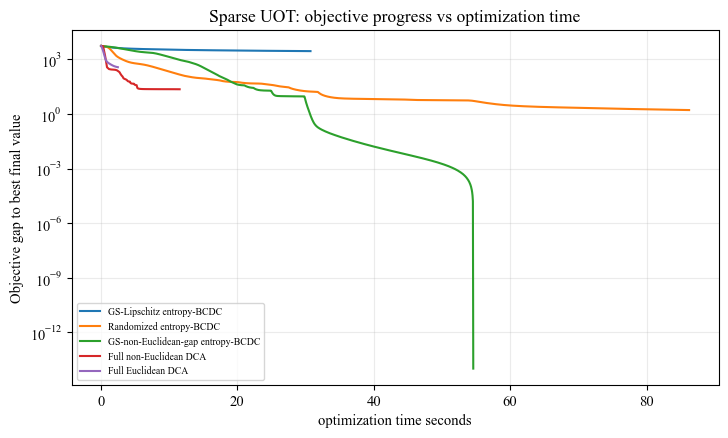

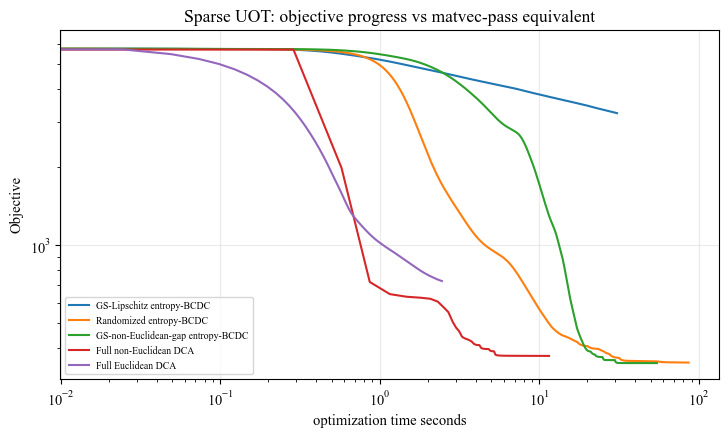

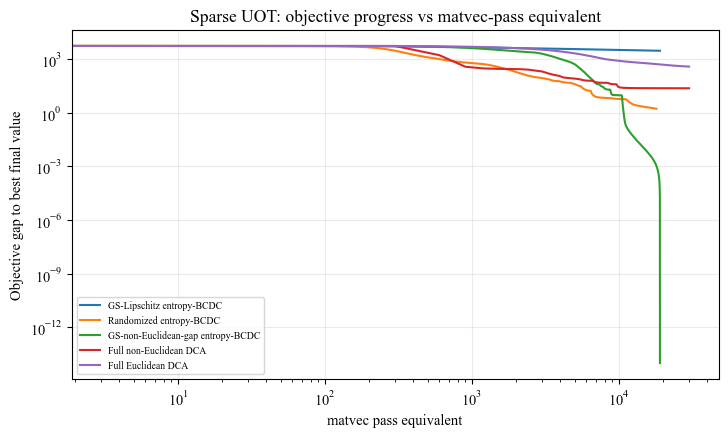

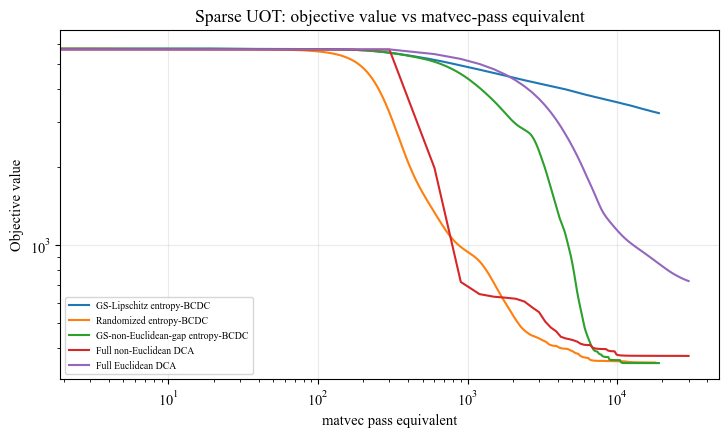

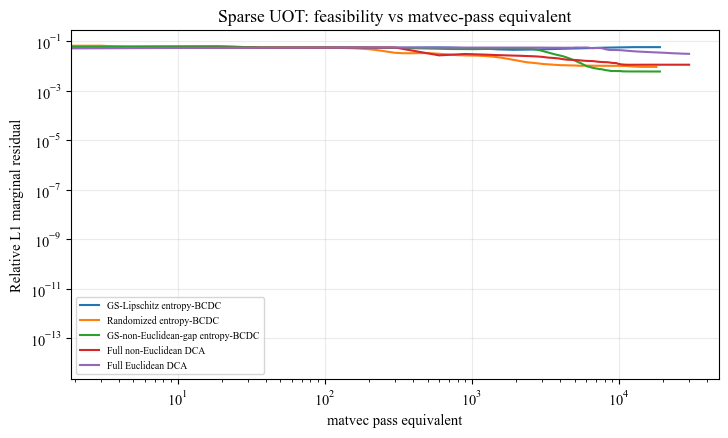

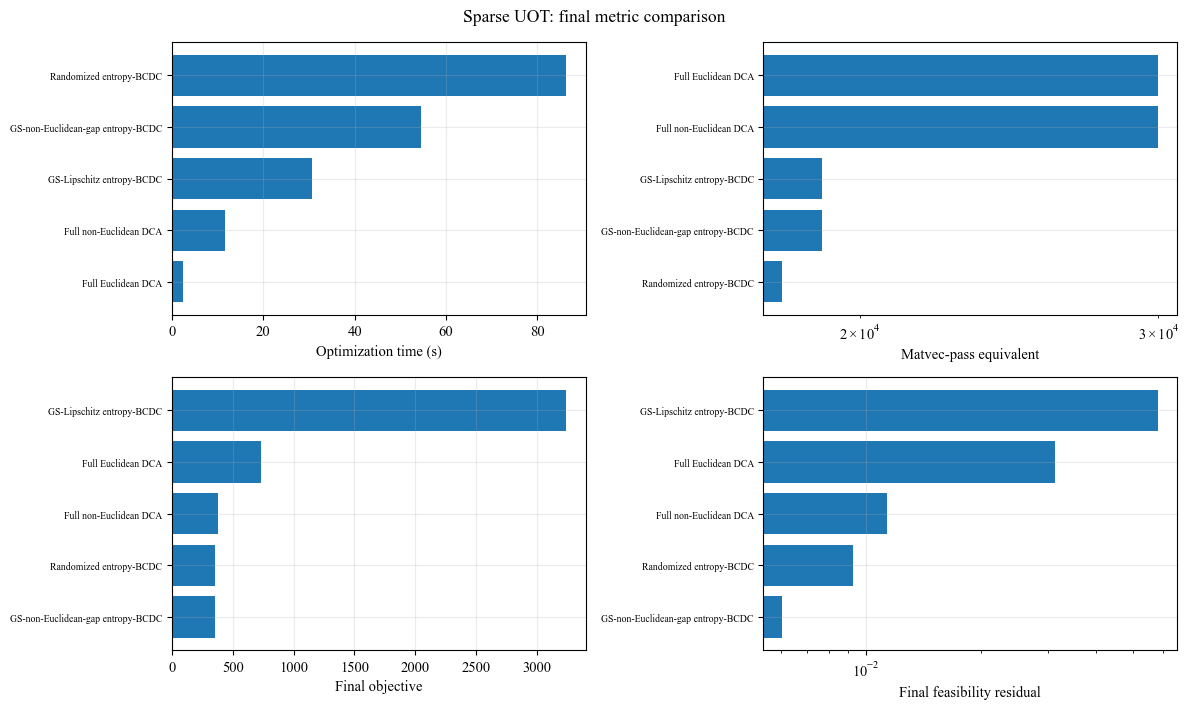

In [261]:
PLOT_METHOD_ORDER = [METHOD_LABELS[key] for key in COMPARISON_METHODS]


def plot_comparison(df, x, y, ylabel, title, logy=False, logx=False):
    fig, ax = plt.subplots()
    for method in PLOT_METHOD_ORDER:
        sub = df[df["method"] == method].sort_values(x)
        if sub.empty:
            continue
        values = sub[y].to_numpy(dtype=float)
        if logy:
            values = np.maximum(values, 1e-14)
        ax.plot(sub[x], values, label=method)
    ax.set_xlabel(x.replace("_", " "))
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if logy:
        ax.set_yscale("log")
    if logx:
        ax.set_xscale("log")
    ax.legend(fontsize=7.0)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_final_metric_bars(df):
    plot_df = df.copy()
    plot_df["method"] = plot_df["method"].astype(str)
    metric_specs = [
        ("optimization_time_seconds", "Optimization time (s)", False),
        ("matvec_pass_equivalent", "Matvec-pass equivalent", True),
        ("objective", "Final objective", False),
        ("marginal_relative_l1_residual", "Final feasibility residual", True),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.2))
    for ax, (metric, xlabel, logx) in zip(axes.flat, metric_specs):
        ordered = plot_df.sort_values(metric, ascending=True)
        ax.barh(ordered["method"], ordered[metric])
        ax.set_xlabel(xlabel)
        if logx:
            ax.set_xscale("log")
        ax.tick_params(axis="y", labelsize=7.0)
        ax.grid(True, axis="x", alpha=0.25)
    fig.suptitle("Sparse UOT: final metric comparison")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


plot_comparison(
    results, "optimization_time_seconds", "objective_gap_to_best_final",
    "Objective gap to best final value",
    "Sparse UOT: objective progress vs optimization time", logy=True,
)
plot_comparison(
    results, "optimization_time_seconds", "objective",
    "Objective",
    "Sparse UOT: objective progress vs matvec-pass equivalent", logy=True, logx=True,
)
plot_comparison(
    results, "matvec_pass_equivalent", "objective_gap_to_best_final",
    "Objective gap to best final value",
    "Sparse UOT: objective progress vs matvec-pass equivalent", logy=True, logx=True,
)
plot_comparison(
    results, "matvec_pass_equivalent", "objective",
    "Objective value",
    "Sparse UOT: objective value vs matvec-pass equivalent", logy=True, logx=True,
)
plot_comparison(
    results, "matvec_pass_equivalent", "marginal_relative_l1_residual",
    "Relative L1 marginal residual",
    "Sparse UOT: feasibility vs matvec-pass equivalent", logy=True, logx=True,
)
plot_final_metric_bars(final_comparison)

## Interpretation notes

- Per-method iteration budgets are resolved from `outer_iterations_by_method`.  For
  `lipschitz`, `uniform`, and `bregman_gap`, this budget is measured in sweeps; for
  `full_entropy` and `full_euclidean`, it is measured in outer frozen-DCA iterations.
- The coordinate BCDC methods now explicitly match the paper's selected-pair step: choose the
  target column, choose an admissible top-$Q$ subgradient for that selected column, then solve
  the selected column surrogate using that fixed subgradient.  The coordinate methods use the
  paper's columnwise entropy smoothness constant on the log trust region set by
  `block_log_radius`; because this sparse-UOT block subproblem has a closed form, there is no
  repeated inner coordinate solve.
- `GS-non-Euclidean-gap` ranks a block by the actual columnwise entropy-surrogate improvement
  using the same local `L_j` and log trust region as the update, not by a Euclidean proxy.
  This is the selection rule most directly aligned with the BCDC geometry.
- Cost accounting matches the Poisson notebook.  A GS batch of `b` dense target columns is
  charged `2*m*b` touched entries for selection, and every coordinate update is charged `3*m`.
  When `sampling="random_reshuffling"`, GS candidate batches are consecutive slices of a
  random column permutation, so every column is scored once per candidate pass.
  The GS scoring implementation is vectorized for wall-clock speed, but the work charge is
  unchanged because the same candidate columns are inspected.
  A full inner update is charged `3*m*n`.
- `Full non-Euclidean DCA` and `Full Euclidean DCA` use frozen DCA subproblems: the top-$Q$
  subgradient is frozen at the outer anchor, and inner full-matrix updates optimize that fixed
  convex surrogate before the anchor is refreshed.
- Feasibility is reported as the larger of the source and target relative L1 marginal residuals.
  This is a diagnostic only: the model is unbalanced OT, so marginal equality is penalized rather
  than enforced as a hard constraint.
- The full gap in the results uses one admissible extreme subgradient of each top-$Q$ term.  It is
  therefore the paper's inner maximization evaluated at that chosen `v`, rather than the additional
  minimization over every `v in partial h(P)`.